In [1]:
import io
import os
import fnmatch
from typing import Optional
import paramiko
import pandas as pd

def fetch_and_concat_csvs(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    pattern: str = "df_metrics*",
    port: int = 22,
    return_csv_string: bool = False,
    timeout: Optional[float] = 10.0,
) -> pd.DataFrame:
    """
    Se connecte en SFTP et télécharge/télécharge en mémoire tous les fichiers
    du dossier `remote_dir` qui correspondent au `pattern` (fnmatch), lit les CSV,
    ajoute une colonne 'file' contenant le nom du fichier, concatène et renvoie
    le DataFrame final.

    Paramètres
    ----------
    ip, user, password : str
        Informations de connexion SSH.
    remote_dir : str
        Dossier distant à parcourir (chemin absolu ou relatif à l'utilisateur SFTP).
    pattern : str
        Pattern shell-style (ex: 'df_metrics*').
    port : int
        Port SSH (par défaut 22).
    return_csv_string : bool
        Si True, renvoie une tuple (DataFrame, csv_string). Sinon seulement DataFrame.
    timeout : float|None
        Timeout connexion en secondes.

    Retour
    ------
    pd.DataFrame
        DataFrame pandas concaténé contenant tous les enregistrements et une colonne 'file'.
        (ou (DataFrame, csv_string) si return_csv_string=True)
    """

    # Prépare le client SSH / SFTP
    transport = None
    sftp = None
    try:
        # Connexion SSH (transport)
        transport = paramiko.Transport((ip, port))
        transport.connect(username=user, password=password)
        # Ouvrir SFTP
        sftp = paramiko.SFTPClient.from_transport(transport)

        # Lister fichiers dans le répertoire distant
        try:
            files = sftp.listdir(remote_dir)
        except IOError:
            # Peut-être remote_dir non trouvé ; relancer en absolu ou lever l'erreur
            raise

        # Filtrer par pattern
        matched = [f for f in files if fnmatch.fnmatch(f, pattern)]
        if not matched:
            # Aucun fichier trouvé : renvoyer DataFrame vide
            empty_df = pd.DataFrame()
            if return_csv_string:
                return empty_df, ""
            return empty_df

        dfs = []
        for fname in matched:
            if 'federated' not in fname:
                continue
            remote_path = os.path.join(remote_dir, fname)
            # Ouvre en binaire, lit tout en mémoire
            with sftp.open(remote_path, "rb") as remote_file:
                raw = remote_file.read()
            # Tenter de lire avec pandas
            # On essaie d'abord BytesIO (pandas gère souvent les bytes),
            # sinon on décode en utf-8 en tolérant les erreurs.
            df = None
            try:
                df = pd.read_csv(io.BytesIO(raw))
            except Exception:
                # try decoding then StringIO
                try:
                    txt = raw.decode("utf-8", errors="replace")
                    df = pd.read_csv(io.StringIO(txt))
                except Exception as e:
                    # En cas d'échec, lever une erreur explicite
                    raise RuntimeError(f"Impossible de parser le CSV distant {remote_path!r}: {e}")

            # Ajouter colonne 'file' avec le nom du fichier (basename)
            df["file"] = os.path.basename(fname)
            dfs.append(df)

        # Concaténer
        final_df = pd.concat(dfs, ignore_index=True, sort=False)

        if return_csv_string:
            csv_str = final_df.to_csv(index=False)
            return final_df, csv_str

        return final_df

    finally:
        # Fermeture propre des connexions
        if sftp is not None:
            try:
                sftp.close()
            except Exception:
                pass
        if transport is not None:
            try:
                transport.close()
            except Exception:
                pass


IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/full_all_departement_0_None_node"

df = fetch_and_concat_csvs(IP, USER, PASSWORD, REMOTE_DIR, pattern="df_metrics*")
print("Lignes totales :", len(df))
print(df.head())

Lignes totales : 20
   Unnamed: 0                                                Run  nbsinister  \
0           0  all_alafederated-GRU-departement-fltg_search_f...      2192.0   
1           1  all_alafederated-DilatedCNN-departement-fltg_s...      2192.0   
2           2  all_alafederated-GRU-mediterranean-fltg_search...      2192.0   
3           3  all_alafederated-DilatedCNN-mediterranean-fltg...      2192.0   
4           0  all_moonfederated-GRU-departement-fltg_search_...      2192.0   

         r2       mse    IV  accuracy   auoc     f1   prec  ...  \
0 -0.619540  0.150233  0.93      0.87  0.736  0.295  0.207  ...   
1 -0.201054  0.111413  0.66      0.92  0.753  0.297  0.275  ...   
2 -0.301813  0.120760  1.57      0.92  0.694  0.427  0.355  ...   
3  0.099934  0.083493  0.72      0.95  0.768  0.320  0.494  ...   
4 -0.548398  0.143634  1.11      0.88  0.726  0.321  0.226  ...   

   f1_macro_predicted_sup_3_class_ez  auoc_predicted_sup_3_class_ez  \
0                        

In [2]:
def select_metrics(df : pd.DataFrame, metrics : list[str]):
    return df[['Run'] + metrics]

#df = select_metrics(df, ['mean_iou_test', 'mean_f1_test', 'mean_prec_test', 'mean_recall_test', 'mean_normalized_iou_test', \
#                         'mean_normalized_f1_test', 'mean_normalized_prec_test', 'mean_normalized_rec_test', \
#                            'mean_iou_elt_sup_3.0_test', 'mean_f1_elt_sup_3.0_test', 'mean_prec_elt_sup_3.0_test', 'mean_rec_elt_sup_3.0_test'])

In [3]:
def parse_run_name_old(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    i += 1
    #dico['Number_of_features'] = vec[i]
    i += 1
    dico['Scale'] = vec[i]
    if 'scale_result' not in dico.keys():
        dico['scale_result'] = vec[i]
    i += 1
    dico['Days_in_futur'] = vec[i]
    i += 1
    dico['Base'] = vec[i]
    i += 1
    dico['Method'] = vec[i]
    i += 1

    if i == len(vec):
        return dico
    if vec[i] == 'kmeans':
        i += 1
        dico['kmeans_shift'] = vec[i]
        i += 1
        dico['kmeans_thresh'] = vec[i]
        i += 1
    return dico
# %%
def parse_run_name_new(x):
    print(x)
    dico = {}
    vec = x.split('_')
    dico['Department'] = vec[0]
    i = 1
    dico['Model'] = vec[i]
    i += 1
    if dico['Model'] == 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1
        dico['Task_type'] = vec[i]
        i += 1
        dico['under_sampling'] = vec[i]
        dico['over_sampling'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
    else:
        dico['under_sampling'] = vec[i]
        i += 1
        dico['over_sampling'] = vec[i]
        i += 1
        dico['kdays'] = vec[i]
        i += 1
        dico['horizon_train'] = vec[i]
        i += 1
        dico['Number_of_features'] = vec[i]
        i += 1
        dico['weight'] = vec[i]
        i += 1
        dico['Target'] = vec[i]
        i += 1

    if dico['Model'] != 'fwi-mean-[5, 10.5, 21.5, 34.5]-5':
        dico['Task_type'] = vec[i]
        i += 1
        dico['loss'] = vec[i]
        i += 1
        dico['horizon'] = vec[i]
        try:
            if vec[i] == 'departement':
                dico['scale_result'] = vec[i]
            else:
                int(vec[i])
                dico['scale_result'] = vec[i]
            i += 1
        except Exception as e:
            try:
                float(vec[i])
                return None
            except:
                pass
            pass
    else:
        dico['loss'] = None
    
    return dico

# Initialisation des colonnes avec des valeurs None
df['Department'] = None
df['Model'] = None
df['Target'] = None
df['Task_type'] = None
df['Drop'] = None
df['Loss_function'] = None
df['under_sampling'] = None
df['over_sampling'] = None
df['kdays'] = None
df['horizon'] = None
df['horizon_train'] = None
df['Number_of_features'] = None
df['Scale'] = None
df['Base'] = None
df['Method'] = None
df['Days_in_futur'] = None
df['weight'] = None
df['kmeans_thresh'] = None
df['kmeans_shift'] = None
df['scale_result'] = None

# Boucle pour remplir les colonnes avec les valeurs de dico_parse
for index, row in df.iterrows():
    try:
        dico_parse = parse_run_name_new(row['Run'])
        if dico_parse is None:
            continue
    except:
        continue
    # Mise à jour de chaque colonne avec les valeurs du dictionnaire dico_parse
    df.loc[index, 'Department'] = dico_parse.get('Department')
    df.loc[index, 'scale_result'] = dico_parse.get('scale_result')
    df.loc[index, 'Drop'] = dico_parse.get('Drop')
    df.loc[index, 'Model'] = dico_parse.get('Model')
    df.loc[index, 'Target'] = dico_parse.get('Target')
    df.loc[index, 'Task_type'] = dico_parse.get('Task_type')
    df.loc[index, 'Loss_function'] = dico_parse.get('loss')
    df.loc[index, 'under_sampling'] = dico_parse.get('under_sampling')
    df.loc[index, 'over_sampling'] = dico_parse.get('over_sampling')
    df.loc[index, 'kdays'] = dico_parse.get('kdays')
    df.loc[index, 'horizon'] = dico_parse.get('horizon')
    df.loc[index, 'horizon_train'] = dico_parse.get('horizon_train')
    df.loc[index, 'Number_of_features'] = dico_parse.get('Number_of_features')
    df.loc[index, 'Scale'] = dico_parse.get('Scale')
    df.loc[index, 'Base'] = dico_parse.get('Base')
    df.loc[index, 'Method'] = dico_parse.get('Method')
    df.loc[index, 'Days_in_futur'] = dico_parse.get('Days_in_futur')

    df.loc[index, 'weight'] = dico_parse.get('weight')
    df.loc[index, 'kmeans_thresh'] = dico_parse.get('kmeans_thresh', 0)
    df.loc[index, 'kmeans_shift'] = dico_parse.get('kmeans_shift', 0)

df['horizon'] = df['horizon'].astype(int)

all_alafederated-GRU-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_alafederated-DilatedCNN-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_alafederated-GRU-mediterranean-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_alafederated-DilatedCNN-mediterranean-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_moonfederated-GRU-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_moonfederated-DilatedCNN-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_moonfederated-GRU-cluster-encoder-fltg_search

/tmp/ipykernel_1164493/1340949067.py:145: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Department'] = None
/tmp/ipykernel_1164493/1340949067.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Model'] = None
/tmp/ipykernel_1164493/1340949067.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy

all_moonfederated-DilatedCNN-saison-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_moonfederated-GRU-mediterranean-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_moonfederated-DilatedCNN-mediterranean-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_federated-GRU-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_federated-DilatedCNN-departement-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_federated-GRU-cluster-encoder-fltg_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss_0_10_full_all_departement_0_None_node
all_federated-DilatedCNN-cluster-encoder-fltg_search_full_

In [4]:
df = df[df['Loss_function'] != 'weightedcrossentropy']

In [5]:
df.Target.unique()

array(['nbsinister-kmeans-5-Class-Dept'], dtype=object)

In [6]:
df[df['Model'] == 'alafederated-GRU-saison-weighted']['Loss_function']

Series([], Name: Loss_function, dtype: object)

In [18]:
import pandas as pd
import numpy as np

def to_latex(df: pd.DataFrame, metrics: list[list[str]], loss: str, targets: list[str]) -> str:
    """
    Génère un tableau LaTeX :
    - une ligne par modèle
    - chaque métrique est affichée comme "mean ± std" avec 2 chiffres après la virgule
    - NaN si la métrique pour un modèle/target n'existe pas
    - filtrage par Loss_function
    """

    # Filtrer par loss
    df = df[df["Loss_function"] == loss]

    if df.empty:
        raise ValueError(f"Aucune ligne trouvée avec Loss_function == '{loss}'")

    # Liste des modèles uniques
    models = df["Model"].unique()

    # Colonnes de métriques
    ordered_metrics = [m for group in metrics for m in group]

    col_format = "l" + "c" * len(ordered_metrics)

    # En-tête
    target_header = ["Model"]
    for target, group in zip(targets, metrics):
        target_header.extend([target] * len(group))
    target_header = " & ".join(target_header) + " \\\\"

    metric_header = [""] + ordered_metrics
    metric_header = " & ".join(metric_header) + " \\\\"

    rows = []

    for model in models:
        values = [model]

        for target_group, target in zip(metrics, targets):
            for m in target_group:
                # colonne std correspondante
                std_col = "std_" + (m[5:] if m.startswith("mean_") else m)

                # Filtrer sur modèle et target exact
                matching_rows = df[(df["Model"] == model) & (df["Target"] == target)]
                if not matching_rows.empty:
                    mean_val = matching_rows.iloc[0].get(m, np.nan)
                    std_val = matching_rows.iloc[0].get(std_col, np.nan)
                    if pd.isna(mean_val) :
                        val = "NaN"
                    else:
                        if pd.isna(std_val):
                            val = f"{mean_val:.2f}"
                        else:
                            val = f"{mean_val:.2f} ± {std_val:.2f}"  # deux chiffres après la virgule
                else:
                    val = "NaN"

                values.append(val)

        rows.append(" & ".join(values) + " \\\\")

    # Construction du tableau LaTeX
    latex = []
    latex.append("\\begin{tabular}{" + col_format + "}")
    latex.append("\\hline")
    latex.append(target_header)
    latex.append(metric_header)
    latex.append("\\hline")
    latex.extend(rows)
    latex.append("\\hline")
    latex.append("\\end{tabular}")

    return "\n".join(latex)

print(to_latex(df, metrics=[['iou_class_hard']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept']))

\begin{tabular}{lc}
\hline
Model & nbsinister-kmeans-5-Class-Dept \\
 & iou_class_hard \\
\hline
alafederated-GRU-departement-fltg & 0.16 \\
alafederated-DilatedCNN-departement-fltg & 0.16 \\
alafederated-GRU-mediterranean-fltg & 0.24 \\
alafederated-DilatedCNN-mediterranean-fltg & 0.16 \\
moonfederated-GRU-departement-fltg & 0.17 \\
moonfederated-DilatedCNN-departement-fltg & 0.03 \\
moonfederated-GRU-cluster-encoder-fltg & 0.22 \\
moonfederated-DilatedCNN-cluster-encoder-fltg & 0.20 \\
moonfederated-GRU-saison-fltg & 0.21 \\
moonfederated-DilatedCNN-saison-fltg & 0.22 \\
moonfederated-GRU-mediterranean-fltg & 0.20 \\
moonfederated-DilatedCNN-mediterranean-fltg & 0.17 \\
federated-GRU-departement-fltg & 0.17 \\
federated-DilatedCNN-departement-fltg & 0.05 \\
federated-GRU-cluster-encoder-fltg & 0.21 \\
federated-DilatedCNN-cluster-encoder-fltg & 0.21 \\
federated-GRU-saison-fltg & 0.20 \\
federated-DilatedCNN-saison-fltg & 0.22 \\
federated-GRU-mediterranean-fltg & 0.22 \\
federated-D

In [8]:
print(to_latex(df, metrics=[['mean_iou_elt_sup_3.0_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept']))

\begin{tabular}{lc}
\hline
Model & nbsinister-kmeans-5-Class-Dept \\
 & mean_iou_elt_sup_3.0_test \\
\hline
alafederated-GRU-departement-fltg & 0.21 \\
alafederated-DilatedCNN-departement-fltg & 0.27 \\
alafederated-GRU-mediterranean-fltg & 0.44 \\
alafederated-DilatedCNN-mediterranean-fltg & 0.20 \\
moonfederated-GRU-departement-fltg & 0.22 \\
moonfederated-DilatedCNN-departement-fltg & 0.02 \\
moonfederated-GRU-cluster-encoder-fltg & 0.24 \\
moonfederated-DilatedCNN-cluster-encoder-fltg & 0.22 \\
moonfederated-GRU-saison-fltg & 0.36 \\
moonfederated-DilatedCNN-saison-fltg & 0.24 \\
moonfederated-GRU-mediterranean-fltg & 0.42 \\
moonfederated-DilatedCNN-mediterranean-fltg & 0.26 \\
federated-GRU-departement-fltg & 0.22 \\
federated-DilatedCNN-departement-fltg & 0.05 \\
federated-GRU-cluster-encoder-fltg & 0.22 \\
federated-DilatedCNN-cluster-encoder-fltg & 0.22 \\
federated-GRU-saison-fltg & 0.37 \\
federated-DilatedCNN-saison-fltg & 0.38 \\
federated-GRU-mediterranean-fltg & 0.39 \\


In [9]:
import torch

int(torch.Tensor([0]))

0

In [10]:
print(to_latex(df, metrics=[['mean_normalized_iou_test']], loss='wkloss',\
               targets=['nbsinister-kmeans-5-Class-Dept']))

\begin{tabular}{lc}
\hline
Model & nbsinister-kmeans-5-Class-Dept \\
 & mean_normalized_iou_test \\
\hline
alafederated-GRU-departement-fltg & 0.08 \\
alafederated-DilatedCNN-departement-fltg & 0.08 \\
alafederated-GRU-mediterranean-fltg & 0.07 \\
alafederated-DilatedCNN-mediterranean-fltg & 0.04 \\
moonfederated-GRU-departement-fltg & 0.08 \\
moonfederated-DilatedCNN-departement-fltg & 0.02 \\
moonfederated-GRU-cluster-encoder-fltg & 0.08 \\
moonfederated-DilatedCNN-cluster-encoder-fltg & 0.08 \\
moonfederated-GRU-saison-fltg & 0.08 \\
moonfederated-DilatedCNN-saison-fltg & 0.07 \\
moonfederated-GRU-mediterranean-fltg & 0.09 \\
moonfederated-DilatedCNN-mediterranean-fltg & 0.06 \\
federated-GRU-departement-fltg & 0.08 \\
federated-DilatedCNN-departement-fltg & 0.04 \\
federated-GRU-cluster-encoder-fltg & 0.08 \\
federated-DilatedCNN-cluster-encoder-fltg & 0.07 \\
federated-GRU-saison-fltg & 0.08 \\
federated-DilatedCNN-saison-fltg & 0.07 \\
federated-GRU-mediterranean-fltg & 0.09 \\
f

In [11]:
[[0]] + [i for i in range(4)]

[[0], 0, 1, 2, 3]

In [12]:
import re
from typing import Iterable, Optional, Union
import pandas as pd
import matplotlib.pyplot as plt

_INT_ID_RE = re.compile(r"^\d+$")  # uniquement entiers positifs (0,1,2,...)

def plot_metric_per_id(
    df: pd.DataFrame,
    metric: str,
    model_col: str = "model",
    models: Optional[Iterable[str]] = None,
    aggregate: Union[str, None] = "mean",
    marker: str = "o",
    ax: Optional[plt.Axes] = None,
):
    """
    Trace, pour chaque modèle, la courbe de la métrique (y) en fonction des id (x).
    Ne conserve que les colonnes dont l'id est un entier : {metric}_{id}_class_hard
    """

    # 1) Identifier les colonnes candidates
    prefix = f"{metric}_"
    suffix = "_class_hard"
    metric_cols_all = [c for c in df.columns if c.startswith(prefix) and c.endswith(suffix)]

    # 2) Extraire et filtrer pour ne garder que les ids entiers
    #    ex. accuracy_12_class_hard -> id_str = "12" -> id_int = 12
    metric_cols: list[str] = []
    ids_int: list[int] = []
    for c in metric_cols_all:
        id_str = c[len(prefix):-len(suffix)]
        if _INT_ID_RE.match(id_str):   # uniquement entiers (positifs)
            metric_cols.append(c)
            ids_int.append(int(id_str))

    if not metric_cols:
        raise ValueError(
            f"No integer-ID columns found matching pattern '{metric}_{{id}}_class_hard'. "
            f"Available columns: {list(df.columns)}"
        )

    # 3) Ordonner par id numérique croissant
    order = sorted(range(len(ids_int)), key=lambda i: ids_int[i])
    ids_sorted = [ids_int[i] for i in order]
    metric_cols_sorted = [metric_cols[i] for i in order]

    # 4) Restreindre aux modèles demandés
    data = df if models is None else df[df[model_col].isin(models)]

    # 5) Agréger si nécessaire
    if aggregate is None:
        if data.duplicated(subset=[model_col]).any():
            raise ValueError(
                "aggregate=None but multiple rows per model detected. "
                "Provide 'aggregate' (e.g., 'mean') or supply one row per model."
            )
        plot_df = data[[model_col] + metric_cols_sorted].set_index(model_col)
    else:
        if aggregate not in {"mean", "median", "max", "min"}:
            raise ValueError("aggregate must be one of {'mean','median','max','min', None}")
        plot_df = data.groupby(model_col, dropna=False)[metric_cols_sorted].agg(aggregate)

    # 6) Tracé
    if ax is None:
        _, ax = plt.subplots(figsize=(15, 4.5))

    for model_name, row in plot_df.iterrows():
        y = row.values.astype(float)
        ax.plot(ids_sorted, y, marker=marker, label=str(model_name))

    ax.set_xlabel("id")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} per id (integer IDs only)")
    ax.grid(True, alpha=0.3)
    ax.legend(title=model_col, loc="best")

    return ax

import re
from typing import Iterable, Optional, Union
import numpy as np
import pandas as pd

_INT_ID_RE = re.compile(r"^\d+$")  # IDs entiers positifs

def count_best_per_id(
    df: pd.DataFrame,
    metric: str,
    model_col: str = "model",
    models: Optional[Iterable[str]] = None,
    aggregate: Union[str, None] = "mean",
    count_ties: bool = True,
    tie_rtol: float = 1e-9,
    tie_atol: float = 1e-12,
) -> pd.DataFrame:
    """
    Compte, pour chaque modèle, le nombre de fois où il atteint le meilleur score
    sur chaque id (colonnes {metric}_{id}_class_hard), en ne gardant que les IDs entiers.

    Paramètres
    ----------
    df : DataFrame contenant au moins `model_col` + colonnes {metric}_{id}_class_hard
    metric : str, nom de la métrique (ex. "accuracy", "f1")
    model_col : str, nom de la colonne identifiant les modèles
    models : iterable[str] ou None, sous-ensemble de modèles à considérer
    aggregate : {"mean","median","max","min", None}
        Si plusieurs lignes par modèle existent, méthode d'agrégation avant comparaison.
        None => attend une seule ligne par modèle.
    count_ties : bool
        Si True, toutes les méthodes à la valeur max (à tolérance près) sont créditées.
        Si False, une seule méthode est choisie (la première après tri lexicographique du nom).
    tie_rtol, tie_atol : float
        Tolérances pour l’égalité flottante via np.isclose.

    Retour
    ------
    DataFrame ordonnée décroissante par 'best_count' :
        columns = [model_col, 'best_count']
    """
    prefix = f"{metric}_"
    suffix = "_class_hard"
    # Colonnes candidates
    metric_cols_all = [c for c in df.columns if c.startswith(prefix) and c.endswith(suffix)]

    # Filtrer pour ne garder que {metric}_{id}_class_hard avec id entier
    metric_cols, ids_int = [], []
    for c in metric_cols_all:
        id_str = c[len(prefix):-len(suffix)]
        if _INT_ID_RE.match(id_str):
            metric_cols.append(c)
            ids_int.append(int(id_str))

    if not metric_cols:
        raise ValueError(
            f"No integer-ID columns found matching pattern '{metric}_{{id}}_class_hard'. "
            f"Available columns: {list(df.columns)}"
        )

    # Ordonner par id numérique
    order = np.argsort(ids_int)
    ids_sorted = [ids_int[i] for i in order]
    metric_cols_sorted = [metric_cols[i] for i in order]

    # Restreindre aux modèles demandés
    data = df if models is None else df[df[model_col].isin(models)]

    # Agrégation éventuelle
    if aggregate is None:
        if data.duplicated(subset=[model_col]).any():
            raise ValueError(
                "aggregate=None but multiple rows per model detected. "
                "Provide 'aggregate' (e.g., 'mean') or supply one row per model."
            )
        wide = data[[model_col] + metric_cols_sorted].set_index(model_col)
    else:
        if aggregate not in {"mean", "median", "max", "min"}:
            raise ValueError("aggregate must be one of {'mean','median','max','min', None}")
        wide = data.groupby(model_col, dropna=False)[metric_cols_sorted].agg(aggregate)

    # Compteur par modèle
    counts = pd.Series(0, index=wide.index, dtype=int)

    # Pour chaque id: trouver le max et créditer le(s) modèle(s)
    for col in metric_cols_sorted:
        col_vals = wide[col].astype(float)
        if col_vals.notna().any():
            max_val = col_vals.max(skipna=True)
            if count_ties:
                winners = col_vals.index[np.isclose(col_vals, max_val, rtol=tie_rtol, atol=tie_atol)]
            else:
                # prendre un seul gagnant de façon déterministe (tri par nom)
                candidates = col_vals.index[np.isclose(col_vals, max_val, rtol=tie_rtol, atol=tie_atol)]
                winners = [sorted(map(str, candidates))[0]]
                # remapper vers l'index d'origine si besoin
                winners = [idx for idx in col_vals.index if str(idx) == winners[0]]
            counts.loc[winners] += 1
        # sinon: toutes NaN -> aucun crédit pour cet id

    # Mettre en forme le résultat ordonné
    out = counts.reset_index()
    out.columns = [model_col, "best_count"]
    out = out.sort_values(["best_count", model_col], ascending=[False, True], kind="mergesort").reset_index(drop=True)
    # Optionnel: renseigner aussi le nombre d'ids considérés
    out.attrs["n_ids_considered"] = len(ids_sorted)

    return out


In [13]:
df.Model.unique()

array(['alafederated-GRU-departement-fltg',
       'alafederated-DilatedCNN-departement-fltg',
       'alafederated-GRU-mediterranean-fltg',
       'alafederated-DilatedCNN-mediterranean-fltg',
       'moonfederated-GRU-departement-fltg',
       'moonfederated-DilatedCNN-departement-fltg',
       'moonfederated-GRU-cluster-encoder-fltg',
       'moonfederated-DilatedCNN-cluster-encoder-fltg',
       'moonfederated-GRU-saison-fltg',
       'moonfederated-DilatedCNN-saison-fltg',
       'moonfederated-GRU-mediterranean-fltg',
       'moonfederated-DilatedCNN-mediterranean-fltg',
       'federated-GRU-departement-fltg',
       'federated-DilatedCNN-departement-fltg',
       'federated-GRU-cluster-encoder-fltg',
       'federated-DilatedCNN-cluster-encoder-fltg',
       'federated-GRU-saison-fltg', 'federated-DilatedCNN-saison-fltg',
       'federated-GRU-mediterranean-fltg',
       'federated-DilatedCNN-mediterranean-fltg'], dtype=object)

In [14]:
df['iou_0_class_hard']

KeyError: 'iou_0_class_hard'

In [ ]:
plot_metric_per_id(df[(df['Model'].isin(['GRU', 'alafederated-GRU-saison-weighted'])) & (df['Loss_function'] == 'wkloss')], 'iou', 'Model')
df['Model'] = df['Model'] + ' ' + df['Loss_function']
count_best_per_id(df, 'iou', 'Model')

ValueError: No integer-ID columns found matching pattern 'iou_{id}_class_hard'. Available columns: ['Unnamed: 0', 'Run', 'nbsinister', 'r2', 'mse', 'IV', 'accuracy', 'auoc', 'f1', 'prec', 'rec', 'bca', 'f1_macro', 'prec_macro', 'rec_macro', 'unknow_sample_proportion', 'iou_class_hard', 'iou_wildfire_or_pred_class_hard', 'iou_wildfire_and_pred_class_hard', 'rec_bin_class_hard', 'prec_bin_class_hard', 'f1_bin_class_hard', 'rec_macro_class_hard', 'prec_macro_class_hard', 'f1_macro_class_hard', 'iou_no_overestimation_class_hard', 'over_bad_prediction_class_hard', 'under_bad_prediction_class_hard', 'bad_prediction_class_hard', 'dice_coefficient_class_hard', 'iou_wildfire_or_pred_0_81.0_class_hard', 'iou_wildfire_and_pred_0_81.0_class_hard', 'iou_no_overestimation_0_81.0_class_hard', 'iou_0_81.0_class_hard', 'rec_bin_0_81.0_class_hard', 'prec_bin_0_81.0_class_hard', 'f1_bin_0_81.0_class_hard', 'rec_macro_0_81.0_class_hard', 'prec_macro_0_81.0_class_hard', 'f1_macro_0_81.0_class_hard', 'auoc_

In [ ]:
from typing import Optional, Dict, Sequence, Tuple, Union
import os
import fnmatch
import pickle
import pandas as pd
import paramiko

def load_prediction(
    ip: str,
    user: str,
    password: str,
    remote_dir: str,
    models: Sequence[str],           # <- liste de modèles
    horizon: Union[int, str],
    return_concat: bool = True      # <- option pour renvoyer aussi un DF concaténé
) -> Union[Dict[str, Optional[pd.DataFrame]],
           Tuple[Dict[str, Optional[pd.DataFrame]], Optional[pd.DataFrame]]]:

    """
    Charge pour chaque modèle de `models` la prédiction la plus récente
    (pickle) depuis le répertoire SFTP:
        {remote_dir}/{model}/H{horizon}/{model}_full_all_departement_0_None_node_z-score_Catboost_all_pred.pkl

    Renvoie:
      - Par défaut: dict {model: DataFrame ou None}
      - Si return_concat=True: (dict, df_concat ou None)
        où df_concat = concaténation verticale de tous les DF non-nuls,
        avec une colonne additionnelle 'model' pour identifier la source.
    """

    # Sécurité: accepte un seul modèle passé par erreur sous forme de str
    if isinstance(models, str):
        models = [models]

    transport = None
    sftp = None
    results: Dict[str, Optional[pd.DataFrame]] = {}

    try:
        # Connexion SFTP unique réutilisée pour tous les modèles
        transport = paramiko.Transport((ip, 22))
        transport.connect(username=user, password=password)
        sftp = paramiko.SFTPClient.from_transport(transport)

        for model in models:
            try:
                model_dir = os.path.join(remote_dir, model, f"H{horizon}")
                # Liste des fichiers présents
                files = sftp.listdir(model_dir)

                # Motif des fichiers attendus
                pattern = f"{model}_full_all_departement_0_None_node_z-score_Catboost_all_pred.pkl"
                matched_files = fnmatch.filter(files, pattern)

                if not matched_files:
                    print(f"[{model}] Aucun fichier ne matche {pattern} dans {model_dir}")
                    results[model] = None
                    continue

                # Tri par date de modif décroissante, on prend le plus récent
                matched_files.sort(
                    key=lambda x: sftp.stat(os.path.join(model_dir, x)).st_mtime,
                    reverse=True
                )
                latest_file = matched_files[0]
                remote_file_path = os.path.join(model_dir, latest_file)

                # Lecture du pickle
                with sftp.open(remote_file_path, "rb") as f:
                    obj = pickle.load(f)

                if isinstance(obj, pd.DataFrame):
                    df = obj
                else:
                    try:
                        df = pd.DataFrame(obj)
                    except Exception:
                        print(f"[{model}] Le pickle n'est pas un DataFrame et n'est pas convertible.")
                        df = None

                results[model] = df

            except FileNotFoundError:
                print(f"[{model}] Répertoire introuvable: {os.path.join(remote_dir, model, f'H{horizon}')} ")
                results[model] = None
            except Exception as e:
                print(f"[{model}] Erreur: {e}")
                results[model] = None

    except Exception as e:
        print(f"Erreur de connexion SFTP: {e}")
        # Si la connexion échoue, retourner un dict None pour tous les modèles
        for m in models:
            results.setdefault(m, None)
    finally:
        # Fermeture propre
        try:
            if sftp is not None:
                sftp.close()
        finally:
            if transport is not None:
                transport.close()

    if not return_concat:
        return results

    # Concatène les DF valides et ajoute la colonne 'model'
    dfs = []
    for m, df in results.items():
        if isinstance(df, pd.DataFrame):
            tmp = df.copy()
            if 'model' not in tmp.columns:
                tmp.insert(0, 'model', m)
            else:
                tmp['model'] = m  # écrase au cas où
            dfs.append(tmp)

    df_concat = pd.concat(dfs, ignore_index=True) if dfs else None
    return df_concat

In [ ]:
IP = "mesohelios1.univ-fcomte.fr"
USER = "ncaron"
PASSWORD = "xp2nrfeu"
REMOTE_DIR = "/Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node"

models_type = ['GRU', 'LSTM', 'NetMLP', 'DilatedCNN', 'graphCastGRU', 'graphCastGRUWithAttentionGAT']

model = [f"alafederated-{mt}-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss" for mt in models_type]
#model = "GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss"

In [ ]:
import datetime as dt

pred = load_prediction(
    ip=IP,
    user=USER,
    password=PASSWORD,
    remote_dir=REMOTE_DIR,
    models=model,
    horizon=0,
)

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res

allDates = find_dates_between('2017-06-12', '2025-01-01')

/tmp/ipykernel_1870516/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


[alafederated-LSTM-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss] Répertoire introuvable: /Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/alafederated-LSTM-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss/H0 
[alafederated-NetMLP-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss] Répertoire introuvable: /Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/alafederated-NetMLP-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss/H0 


/tmp/ipykernel_1870516/4192341636.py:70: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  obj = pickle.load(f)


[alafederated-graphCastGRU-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss] Répertoire introuvable: /Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/alafederated-graphCastGRU-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss/H0 
[alafederated-graphCastGRUWithAttentionGAT-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss] Répertoire introuvable: /Home/Users/ncaron/WORK/GNN/bdiff/firepoint/2x2/test/occurence_default/all/full_all_departement_0_None_node/alafederated-graphCastGRUWithAttentionGAT-saison-weighted_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_wkloss/H0 


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from typing import Dict, Tuple, Optional, List

def mean_confusion_by_model(
    df: pd.DataFrame,
    target_col: str,
    prediction_col: str,
    model_col: str = "Model",
    labels: Optional[List[str]] = None,  # libellés d'affichage
    classes: Optional[List[int]] = None, # ordre des classes pour la matrice (ex: [0,1,2,3,4])
    weighted: bool = False,              # moyenne pondérée par la taille du groupe
    plot: bool = True,
    figsize: Tuple[int, int] = (7, 6),
    title: str = "Mean normalized confusion matrix by model",
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Retourne:
      - mean_cm: matrice de confusion moyenne (normalisée par les valeurs de target)
      - per_model_cms: dict {nom_model: matrice_normalisée}
    """
    # Nettoyage minimal
    data = df[[target_col, prediction_col, model_col]].dropna()

    # Détermine l'ordre des classes (stabilité des dimensions)
    if classes is None:
        # union des valeurs présentes dans target et preds
        uniq = pd.Index(np.union1d(data[target_col].unique(), data[prediction_col].unique()))
        # on essaie d'ordonner naturellement si ce sont des entiers
        try:
            classes = sorted(uniq.astype(int).tolist())
        except Exception:
            classes = uniq.tolist()

    n_classes = len(classes)

    # Libellés par défaut (5 classes)
    if labels is None:
        labels = [
            "No fire",
            "Small number of fire",
            "Medium number of fire",
            "High number of fire",
            "Extreme number of fire",
        ]
    if len(labels) != n_classes:
        raise ValueError(
            f"Le nombre de labels ({len(labels)}) ne correspond pas au nombre de classes ({n_classes})."
        )

    # Calcul par modèle
    per_model_cms: Dict[str, np.ndarray] = {}
    weights = []
    for model_name, g in data.groupby(model_col):
        y_true = g[target_col].to_numpy()
        y_pred = g[prediction_col].to_numpy()

        # matrice normalisée par les valeurs vraies (lignes)
        cm = confusion_matrix(
            y_true, y_pred, labels=classes, normalize="true"
        ).astype(float)
        per_model_cms[model_name] = cm
        weights.append(len(g))

    if not per_model_cms:
        raise ValueError("Aucun groupe modèle trouvé après nettoyage des données.")

    # Moyenne (pondérée ou non)
    cms_stack = np.stack(list(per_model_cms.values()), axis=0)  # (M, C, C)
    if weighted:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
        mean_cm = np.tensordot(w, cms_stack, axes=(0, 0))
    else:
        mean_cm = cms_stack.mean(axis=0)

    # Tracé optionnel
    if plot:
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(mean_cm, interpolation="nearest", cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticks(np.arange(n_classes))
        ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_yticklabels(labels)

        # Valeurs dans les cases
        thresh = mean_cm.max() / 2.0
        for i in range(n_classes):
            for j in range(n_classes):
                val = mean_cm[i, j]
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()

    return mean_cm, per_model_cms

In [ ]:
import numpy as np

def ordinal_ece(probs, y_true, n_bins=10):
    """
    probs: (N, K) probas prédites pour chaque classe ordinale
    y_true: (N,) labels réels {0..K-1}
    """
    N, K = probs.shape
    ece = 0.0
    bin_edges = np.linspace(0, 1, n_bins+1)

    # Convertir probas en CDF ordinale
    cdf_pred = np.cumsum(probs, axis=1)  # shape (N, K)
    
    # On ne considère pas la classe max (CDF==1)
    for k in range(K-1):
        conf_k = cdf_pred[:, k]          # P(Y <= k)
        true_k = (y_true <= k).astype(float)

        for b in range(n_bins):
            # indices du bin
            in_bin = (conf_k >= bin_edges[b]) & (conf_k < bin_edges[b+1])
            if not np.any(in_bin):
                continue

            freq = np.mean(true_k[in_bin])
            conf = np.mean(conf_k[in_bin])
            ece += (np.sum(in_bin) / N) * abs(freq - conf)
            
    return ece

In [ ]:
target_name = 'nbsinister-kmeans-5-Class-Dept'
horizon = 0
cols = list([f'prediction_{target_name}_{horizon}_C{c}' for c in range(5)])

probs = pred.groupby(['date', 'graph_id'])[cols].mean().values
ytrue = pred.groupby(['date', 'graph_id'])[target_name].mean().values

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_calibration_with_background(
    probs,
    y_true,
    n_bins=10,
    ks=None,
    figsize=(25, 5),
    title="Calibration",
    average="micro",
    eps=1e-12,
    show_bin_counts=True,
    classwise=True,     # nominal one-vs-rest (existant)
    tailwise=False,     # <<< NOUVEAU : calibration P(Y >= c | Y>0) par seuil c
):
    """
    Modes disponibles :
      - classwise=True  (nominal one-vs-rest, un panneau par classe P(Y=c))
      - tailwise=True   (nouveau) calibration de queue conditionnelle P(Y >= c | Y>0)
      - sinon : mode ordinal conditionnel (CDF) + binaire P(Y>0) comme avant.

    tailwise:
      * On restreint aux échantillons positifs (Y>0 et p_pos>eps)
      * Pour chaque c in {1..K-1}, on trace:
            conf_c = P_hat(Y>=c | Y>0) = 1 - CDF_pos(c-1)
            true_c = 1[(Y>=c) | Y>0]
        et on calcule une ECE par c.
    """
    probs = np.asarray(probs, float)
    y_true = np.asarray(y_true, int)
    N, K = probs.shape

    if classwise and tailwise:
        raise ValueError("Use either classwise=True or tailwise=True, not both.")

    bins = np.linspace(0, 1, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # ----------------------- MODE NOMINAL (par classe) ----------------------- #
    if classwise and not tailwise:
        n_panels = K
        fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
        if n_panels == 1:
            axes = [axes]

        eces = []
        stats = {"ECE_event": None, "mode": "classwise"}

        for c in range(K):
            p = probs[:, c]
            t = (y_true == c).astype(float)

            conf_means, freq_means, counts = [], [], []
            ece_c = 0.0; used_bins = 0

            for b in range(n_bins):
                lo, hi = bins[b], bins[b + 1]
                mask = (p >= lo) & (p < hi if b < n_bins - 1 else p <= hi)
                nb = int(mask.sum()); counts.append(nb)
                if nb == 0:
                    conf_means += [np.nan]; freq_means += [np.nan]; continue
                cm = p[mask].mean(); fm = t[mask].mean()
                conf_means.append(cm); freq_means.append(fm)
                if average == "micro":
                    ece_c += (nb / N) * abs(fm - cm)
                else:
                    ece_c += abs(fm - cm); used_bins += 1
            if average == "macro" and used_bins > 0:
                ece_c /= used_bins

            eces.append(ece_c)
            ax = axes[c]
            conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
            valid = np.isfinite(conf_means) & np.isfinite(freq_means)
            ax.plot([0,1],[0,1],"k:",lw=1)
            ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_c:.3f}")
            ax.set_title(f"Class {c}")
            ax.set_xlabel(f"P(Y = {c})"); ax.set_ylabel(f"Observed freq. (Y = {c})")
            ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
            if show_bin_counts:
                ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
            stats[f"ECE_class_{c}"] = float(ece_c)
            
        eces = np.array(eces, float)
        stats["ECE_macro_over_classes"] = float(np.nanmean(eces))
        stats["ECE_micro_over_classes"] = float(np.nansum(eces)) if average == "micro" else None
        fig.tight_layout()
        return fig, axes, stats

    # ----------------------- MODE TAILWISE (NOUVEAU) ------------------------ #
    if tailwise:
        # Positifs : normalisation conditionnelle
        p_pos = 1 - probs[:, 0]
        mask_pos = p_pos > eps
        if not np.any(mask_pos):
            raise ValueError("No samples with positive-event probability above eps.")
        cond_probs = probs[mask_pos, 1:] / p_pos[mask_pos, None]
        y_pos = y_true[mask_pos]
        mask_truepos = y_pos > 0
        cond_probs = cond_probs
        y_pos = y_pos
        if cond_probs.shape[0] == 0:
            raise ValueError("No positive ground-truth samples for tailwise calibration.")

        N2, Kp = cond_probs.shape  # Kp = K-1 (classes 1..K-1)
        cdf_pos = np.cumsum(cond_probs, axis=1)  # CDF sur {1..K-1}
        # Pour c in {1..K-1}, P(Y>=c | Y>0) = 1 - CDF_pos(c-1)
        classes_c = list(range(1, K))
        n_panels = len(classes_c)
        fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
        if n_panels == 1: axes = [axes]

        stats = {"mode": "tailwise"}
        for j, c in enumerate(classes_c):
            ax = axes[j]
            conf_tail = 1.0 - cdf_pos[:, c-1]          # prédite P(Y>=c | Y>0)
            true_tail = (y_pos >= c).astype(float)     # observée 1[Y>=c] (sur positifs)

            conf_means, freq_means, counts = [], [], []
            ece_c = 0.0; used_bins = 0
            for b in range(n_bins):
                lo, hi = bins[b], bins[b+1]
                m = (conf_tail >= lo) & (conf_tail < hi if b < n_bins-1 else conf_tail <= hi)
                nb = int(m.sum()); counts.append(nb)
                if nb == 0:
                    conf_means += [np.nan]; freq_means += [np.nan]; continue
                cm = conf_tail[m].mean(); fm = true_tail[m].mean()
                conf_means.append(cm); freq_means.append(fm)
                if average == "micro":
                    ece_c += (nb / N2) * abs(fm - cm)
                else:
                    ece_c += abs(fm - cm); used_bins += 1
            if average == "macro" and used_bins > 0:
                ece_c /= used_bins

            conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
            valid = np.isfinite(conf_means) & np.isfinite(freq_means)
            ax.plot([0,1],[0,1],"k:",lw=1)
            ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_c:.3f}")
            ax.set_title(f"Tail threshold c={c}")
            ax.set_xlabel(f"P(Y ≥ {c} | Y>0)")
            ax.set_ylabel(f"Observed freq. (Y ≥ {c} | Y>0)")
            ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
            if show_bin_counts:
                ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
            stats[f"ECE_tail_c{c}"] = float(ece_c)

        fig.tight_layout()
        return fig, axes, stats

    # ----------------------- MODE ORDINAL (CDF + binaire) ------------------- #
    # (comportement existant, inchangé)
    p_event = 1.0 - probs[:, 0]  # P(Y>0)
    y_event = (y_true > 0).astype(int)

    def binary_ece(p, y):
        ece = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            mask = (p >= lo) & (p < hi if b < n_bins - 1 else p <= hi)
            nb = mask.sum()
            if nb == 0:
                continue
            conf = p[mask].mean()
            freq = y[mask].mean()
            ece += (nb / N) * abs(freq - conf)
        return float(ece)

    ece_event = binary_ece(p_event, y_event)

    p_pos = 1 - probs[:, 0]
    mask_pos = p_pos > eps
    cond_probs = probs[mask_pos, 1:] / p_pos[mask_pos, None]
    y_pos = y_true[mask_pos]
    mask_truepos = y_pos > 0
    cond_probs = cond_probs[mask_truepos]
    y_pos = y_pos[mask_truepos]
    if cond_probs.shape[0] == 0:
        raise ValueError("No positive samples available for conditional calibration.")

    N2, Kp = cond_probs.shape
    cdf = np.cumsum(cond_probs, axis=1)
    if ks is None: ks = list(range(Kp - 1))

    n_panels = 1 + len(ks)
    fig, axes = plt.subplots(1, n_panels, figsize=(max(10, 3 * n_panels), figsize[1]))
    if n_panels == 1: axes = [axes]

    def plot_binary(ax):
        print('here')
        conf_means, freq_means, counts = [], [], []
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (p_event >= lo) & (p_event < hi if b < n_bins - 1 else p_event <= hi)
            nb = m.sum(); counts.append(nb)
            if nb == 0: conf_means += [np.nan]; freq_means += [np.nan]; continue
            conf_means.append(p_event[m].mean()); freq_means.append(y_event[m].mean())
        conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
        valid = np.isfinite(conf_means) & np.isfinite(freq_means)
        ax.plot([0,1],[0,1],"k:",lw=1)
        ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_event:.3f}")
        ax.set_title("Binary: Event occurrence")
        ax.set_xlabel("Predicted probability (event)"); ax.set_ylabel("Observed frequency (event)")
        ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
        if show_bin_counts:
            ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])

    print("here")
    plot_binary(axes[0])

    stats = {"ECE_event": ece_event, "mode": "ordinal"}
    for j, k in enumerate(ks, start=1):
        ax = axes[j]
        conf_k = cdf[:, k]
        true_k = ((y_pos - 1) <= k).astype(float)  # ≡ (y_pos <= k+1)

        conf_means, freq_means, counts = [], [], []
        ece_k = 0.0
        for b in range(n_bins):
            lo, hi = bins[b], bins[b + 1]
            m = (conf_k >= lo) & (conf_k < hi if b < n_bins - 1 else conf_k <= hi)
            nb = m.sum(); counts.append(nb)
            if nb == 0: conf_means += [np.nan]; freq_means += [np.nan]; continue
            cm = conf_k[m].mean(); fm = true_k[m].mean()
            conf_means.append(cm); freq_means.append(fm)
            ece_k += (nb / N2) * abs(fm - cm)

        conf_means, freq_means, counts = map(np.asarray, (conf_means, freq_means, counts))
        valid = np.isfinite(conf_means) & np.isfinite(freq_means)
        ax.plot([0,1],[0,1],"k:",lw=1)
        ax.plot(conf_means[valid], freq_means[valid], "o-", lw=2, label=f"ECE = {ece_k:.3f}")
        ax.set_title(f"Conditional ordinal threshold k'={k}")
        ax.set_xlabel(f"P(Y <= {k+1} | Y>0)"); ax.set_ylabel(f"Observed freq. (Y <= {k+1} | Y>0)")
        ax.set_xlim(0,1); ax.set_ylim(0,1.1); ax.grid(alpha=0.3)
        if show_bin_counts:
            ax2 = ax.twinx(); ax2.bar(centers, counts, width=(bins[1]-bins[0])*0.9, alpha=0.12); ax2.set_yticks([])
        stats[f"ECE_kprime_{k}"] = float(ece_k)

    fig.tight_layout()
    return fig, axes, stats

3.93755972288581


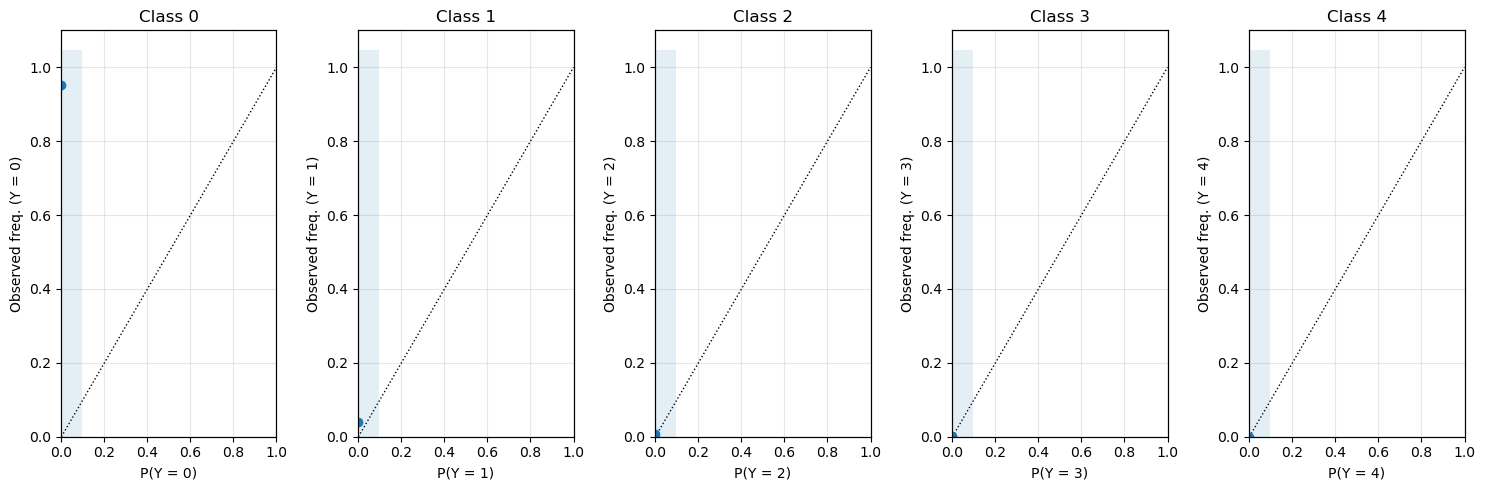

In [ ]:
print(ordinal_ece(probs, ytrue))
plot_calibration_with_background(probs, ytrue)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from typing import Dict, Tuple, Optional, List

def mean_confusion_by_model(
    df: pd.DataFrame,
    target_col: str,
    prediction_col: str,
    model_col: str = "Model",
    labels: Optional[List[str]] = None,  # libellés d'affichage
    classes: Optional[List[int]] = None, # ordre des classes pour la matrice (ex: [0,1,2,3,4])
    weighted: bool = False,              # moyenne pondérée par la taille du groupe
    plot: bool = True,
    figsize: Tuple[int, int] = (7, 6),
    title: str = "Mean normalized confusion matrix by model",
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Retourne:
      - mean_cm: matrice de confusion moyenne (normalisée par les valeurs de target)
      - per_model_cms: dict {nom_model: matrice_normalisée}
    """
    # Nettoyage minimal
    data = df[[target_col, prediction_col, model_col]].dropna()

    # Détermine l'ordre des classes (stabilité des dimensions)
    if classes is None:
        # union des valeurs présentes dans target et preds
        uniq = pd.Index(np.union1d(data[target_col].unique(), data[prediction_col].unique()))
        # on essaie d'ordonner naturellement si ce sont des entiers
        try:
            classes = sorted(uniq.astype(int).tolist())
        except Exception:
            classes = uniq.tolist()

    n_classes = len(classes)

    # Libellés par défaut (5 classes)
    if labels is None:
        labels = [
            "No fire",
            "Small number of fire",
            "Medium number of fire",
            "High number of fire",
            "Extreme number of fire",
        ]
    if len(labels) != n_classes:
        raise ValueError(
            f"Le nombre de labels ({len(labels)}) ne correspond pas au nombre de classes ({n_classes})."
        )

    # Calcul par modèle
    per_model_cms: Dict[str, np.ndarray] = {}
    weights = []
    for model_name, g in data.groupby(model_col):
        y_true = g[target_col].to_numpy()
        y_pred = g[prediction_col].to_numpy()

        # matrice normalisée par les valeurs vraies (lignes)
        cm = confusion_matrix(
            y_true, y_pred, labels=classes, normalize="true"
        ).astype(float)
        per_model_cms[model_name] = cm
        weights.append(len(g))

    if not per_model_cms:
        raise ValueError("Aucun groupe modèle trouvé après nettoyage des données.")

    # Moyenne (pondérée ou non)
    cms_stack = np.stack(list(per_model_cms.values()), axis=0)  # (M, C, C)
    if weighted:
        w = np.array(weights, dtype=float)
        w = w / w.sum()
        mean_cm = np.tensordot(w, cms_stack, axes=(0, 0))
    else:
        mean_cm = cms_stack.mean(axis=0)

    # Tracé optionnel
    if plot:
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(mean_cm, interpolation="nearest", cmap="Blues")
        #ax.set_title(title)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_xticks(np.arange(n_classes))
        ax.set_yticks(np.arange(n_classes))
        ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_yticklabels(labels)

        # Valeurs dans les cases
        thresh = mean_cm.max() / 2.0
        for i in range(n_classes):
            for j in range(n_classes):
                val = mean_cm[i, j]
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    color="white" if val > thresh else "black",
                )

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()

    return mean_cm, per_model_cms

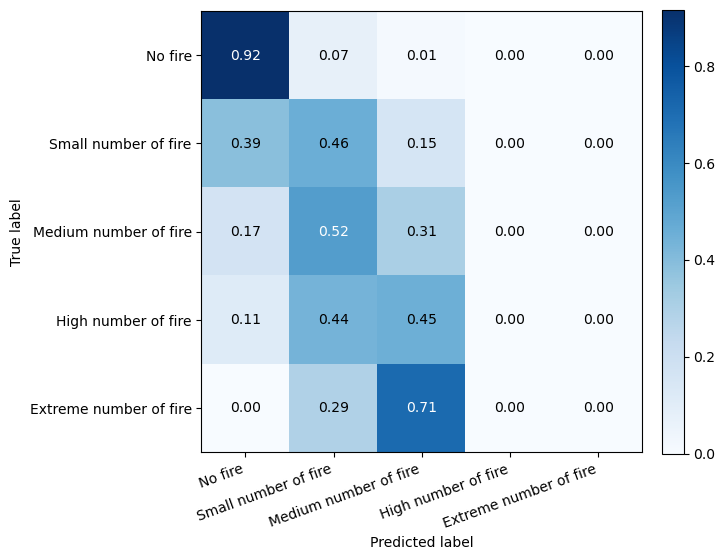

In [ ]:
# df contient les colonnes: "Model", "y_true", "y_pred"
mean_cm, per_model = mean_confusion_by_model(
    pred,
    target_col=target_name,
    prediction_col=f'prediction_{target_name}_0',
    model_col="model",
    classes=[0,1,2,3,4],  # garantit l’ordre 0→4
    # labels peut être omis pour utiliser les libellés par défaut
    plot=True
)